In [1]:
# ── ModMatrix exploration ────────────────────────────────────────────────────
import caspy as cp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Audio
import math

SR = 44100

In [2]:
# ── 1. Basic registration and routing ───────────────────────────────────────
# Demonstrate the register → route → process → read cycle.

freq_param = cp.ModulatableParameter(20.0, 2000.0, 0.5)
freq_param.set_range(20.0, 2000.0, cp.ParameterScale.Logarithmic)
freq_param.skip(1000)

matrix = cp.ModMatrix()
dest_id = matrix.register_parameter(freq_param)
print(f'Registered freq_param as destination {dest_id}')
print(f'Num parameters: {matrix.get_num_parameters()}')

# Source 0: an LFO value we'll push manually
routing = cp.ModulationRouting(0, dest_id, 0.3)
matrix.add_routing(routing)
matrix.process()  # drain the command queue
print(f'Num routings: {matrix.get_num_routings()}')

# Push a source value and process one block
matrix.set_source_value(0, 0.5)   # source 0 = 0.5
matrix.process()
freq_param.process()
print(f'freq value with mod:    {freq_param.value():.2f} Hz')
print(f'freq normalised:        {freq_param.value_normalised():.4f}')

# Zero the source — param should return toward base
matrix.set_source_value(0, 0.0)
matrix.process()
freq_param.process()
print(f'freq value without mod: {freq_param.value():.2f} Hz')

Registered freq_param as destination 0
Num parameters: 1
Num routings: 1
freq value with mod:    200.00 Hz
freq normalised:        0.6500
freq value without mod: 200.00 Hz


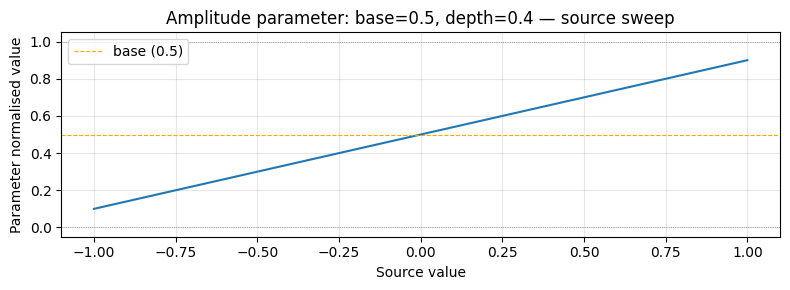

Expected range: [0.10, 0.90]  (clamped to [0,1])
Actual range:   [0.1000, 0.9000]


In [3]:
# ── 2. Sweep source value → observe parameter response ──────────────────────
# One routing, depth=0.4. Sweep source from -1 to +1 and record output.

amp_param = cp.ModulatableParameter(0.0, 1.0, 0.5)
amp_param.skip(1000)

mat2  = cp.ModMatrix()
d_amp = mat2.register_parameter(amp_param)
mat2.add_routing(cp.ModulationRouting(0, d_amp, 0.4))
mat2.process()

source_vals = np.linspace(-1.0, 1.0, 200)
out_vals    = np.empty(200)

for i, sv in enumerate(source_vals):
    mat2.set_source_value(0, float(sv))
    mat2.process()
    amp_param.process()
    out_vals[i] = amp_param.value_normalised()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(source_vals, out_vals)
ax.axhline(0.5, color='orange', linestyle='--', linewidth=0.8, label='base (0.5)')
ax.axhline(0.0, color='grey',   linestyle=':',  linewidth=0.6)
ax.axhline(1.0, color='grey',   linestyle=':',  linewidth=0.6)
ax.set_xlabel('Source value')
ax.set_ylabel('Parameter normalised value')
ax.set_title('Amplitude parameter: base=0.5, depth=0.4 — source sweep')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Expected range: [{0.5 - 0.4:.2f}, {0.5 + 0.4:.2f}]  (clamped to [0,1])')
print(f'Actual range:   [{out_vals.min():.4f}, {out_vals.max():.4f}]')

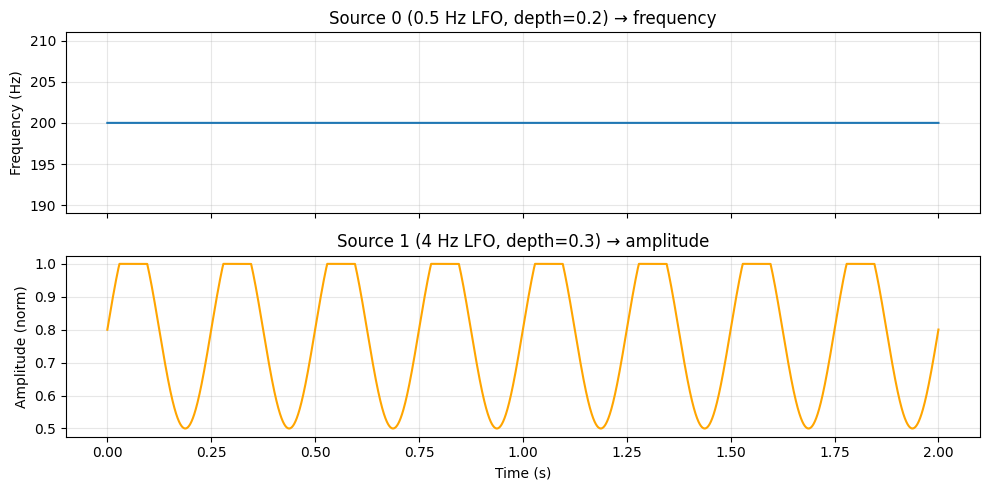

In [4]:
# ── 3. Multiple sources, multiple destinations ───────────────────────────────
# Two LFO sources routed to two parameters. Verify independence.

import caspy.lfo as lfo_mod

p_freq = cp.ModulatableParameter(20.0, 2000.0, 0.5)
p_amp  = cp.ModulatableParameter(0.0,  1.0,    0.8)
p_freq.set_range(20.0, 2000.0, cp.ParameterScale.Logarithmic)
p_freq.skip(1000)
p_amp.skip(1000)

mat3   = cp.ModMatrix()
d_freq = mat3.register_parameter(p_freq)
d_amp  = mat3.register_parameter(p_amp)

# Source 0 → freq, source 1 → amp, source 0 → amp (two routings to same dest)
mat3.add_routing(cp.ModulationRouting(0, d_freq, 0.2))
mat3.add_routing(cp.ModulationRouting(1, d_amp,  0.3))
mat3.process()

lfo_slow = lfo_mod.LFO(float(SR), 0.5)   # 0.5 Hz → freq
lfo_fast = lfo_mod.LFO(float(SR), 4.0)   # 4 Hz → amp

n        = SR * 2
freq_out = np.empty(n)
amp_out  = np.empty(n)

for i in range(n):
    mat3.set_source_value(0, lfo_slow.render_sample())
    mat3.set_source_value(1, lfo_fast.render_sample())
    mat3.process()
    p_freq.process()
    p_amp.process()
    freq_out[i] = p_freq.value()
    amp_out[i]  = p_amp.value_normalised()

t = np.arange(n) / SR
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, freq_out)
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Source 0 (0.5 Hz LFO, depth=0.2) → frequency')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, amp_out, color='orange')
axes[1].set_ylabel('Amplitude (norm)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Source 1 (4 Hz LFO, depth=0.3) → amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

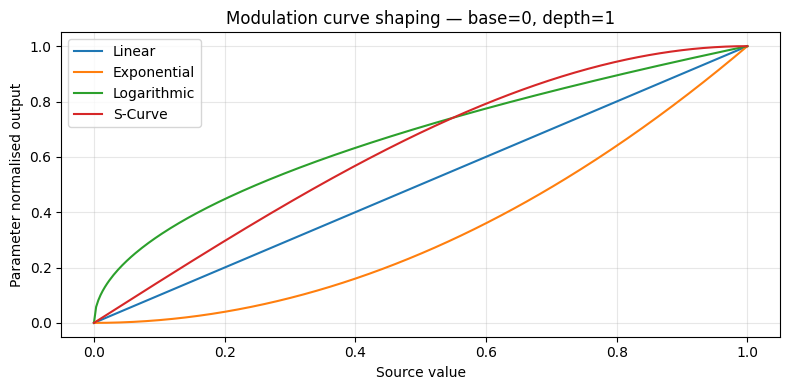

In [5]:
# ── 4. Curve shaping ─────────────────────────────────────────────────────────
# Same source value, four different curve types, compare output.

curves = [
    (cp.ModulationCurve.Linear,      'Linear'),
    (cp.ModulationCurve.Exponential, 'Exponential'),
    (cp.ModulationCurve.Logarithmic, 'Logarithmic'),
    (cp.ModulationCurve.SCurve,      'S-Curve'),
]

source_vals = np.linspace(0.0, 1.0, 300)
results     = {}

for curve, label in curves:
    p = cp.ModulatableParameter(0.0, 1.0, 0.0)
    p.skip(1000)
    mat = cp.ModMatrix()
    d   = mat.register_parameter(p)
    r   = cp.ModulationRouting(0, d, 1.0)
    r.curve = curve
    mat.add_routing(r)
    mat.process()

    out = np.empty(len(source_vals))
    for i, sv in enumerate(source_vals):
        mat.set_source_value(0, float(sv))
        mat.process()
        p.process()
        out[i] = p.value_normalised()
    results[label] = out

fig, ax = plt.subplots(figsize=(8, 4))
for label, out in results.items():
    ax.plot(source_vals, out, label=label)
ax.set_xlabel('Source value')
ax.set_ylabel('Parameter normalised output')
ax.set_title('Modulation curve shaping — base=0, depth=1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ── 5. Enable / disable routing ──────────────────────────────────────────────

p5  = cp.ModulatableParameter(0.0, 1.0, 0.5)
p5.skip(1000)
mat5 = cp.ModMatrix()
d5   = mat5.register_parameter(p5)
mat5.add_routing(cp.ModulationRouting(0, d5, 0.4))
mat5.process()

mat5.set_source_value(0, 0.8)
mat5.process(); p5.process()
print(f'Routing enabled:  {p5.value_normalised():.4f}')

mat5.set_routing_enabled(0, False)
mat5.process(); p5.process()
print(f'Routing disabled: {p5.value_normalised():.4f}  (expected ~0.5 base)')

mat5.set_routing_enabled(0, True)
mat5.process(); p5.process()
print(f'Routing re-enabled: {p5.value_normalised():.4f}')

Routing enabled:  0.8200
Routing disabled: 0.5000  (expected ~0.5 base)
Routing re-enabled: 0.8200


In [7]:
# ── 6. clear_routings ────────────────────────────────────────────────────────

p6   = cp.ModulatableParameter(0.0, 1.0, 0.5)
p6.skip(1000)
mat6 = cp.ModMatrix()
d6   = mat6.register_parameter(p6)
for i in range(4):
    mat6.add_routing(cp.ModulationRouting(i, d6, 0.1))
mat6.process()
print(f'Before clear: {mat6.get_num_routings()} routings')

mat6.set_source_value(0, 1.0)
mat6.process(); p6.process()
print(f'Value with routings:  {p6.value_normalised():.4f}')

mat6.clear_routings()
mat6.process(); p6.process()
print(f'After clear: {mat6.get_num_routings()} routings')
print(f'Value after clear:    {p6.value_normalised():.4f}  (expected ~0.5)')

Before clear: 4 routings
Value with routings:  0.6000
After clear: 0 routings
Value after clear:    0.5000  (expected ~0.5)


In [8]:
# ── 7. Interactive: route LFO to parameter, adjust depth ────────────────────

p_i   = cp.ModulatableParameter(0.0, 1.0, 0.5)
p_i.skip(1000)
mat_i = cp.ModMatrix()
d_i   = mat_i.register_parameter(p_i)
mat_i.add_routing(cp.ModulationRouting(0, d_i, 0.3))
mat_i.process()

w_depth  = widgets.FloatSlider(value=0.3, min=0.0, max=1.0, step=0.01,
                                description='Depth', continuous_update=False)
w_rate   = widgets.FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1,
                                description='LFO rate', continuous_update=False)
w_base   = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05,
                                description='Base norm', continuous_update=False)
w_curve  = widgets.Dropdown(
    options=['Linear', 'Exponential', 'Logarithmic', 'SCurve'],
    value='Linear', description='Curve')
out_mm   = widgets.Output()

curve_map = {
    'Linear':      cp.ModulationCurve.Linear,
    'Exponential': cp.ModulationCurve.Exponential,
    'Logarithmic': cp.ModulationCurve.Logarithmic,
    'SCurve':      cp.ModulationCurve.SCurve,
}

def update_mm(_):
    # Rebuild matrix with current settings
    p = cp.ModulatableParameter(0.0, 1.0, w_base.value)
    p.skip(1000)
    mat = cp.ModMatrix()
    d   = mat.register_parameter(p)
    r   = cp.ModulationRouting(0, d, w_depth.value)
    r.curve = curve_map[w_curve.value]
    mat.add_routing(r)
    mat.process()

    lfo = lfo_mod.LFO(float(SR), w_rate.value)
    n   = SR
    out = np.empty(n)
    for i in range(n):
        mat.set_source_value(0, lfo.render_sample())
        mat.process()
        p.process()
        out[i] = p.value_normalised()

    t = np.arange(n) / SR
    with out_mm:
        out_mm.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(t, out)
        ax.axhline(w_base.value, color='orange', linestyle='--',
                   linewidth=0.8, label=f'base={w_base.value:.2f}')
        ax.axhline(0.0, color='grey', linestyle=':', linewidth=0.5)
        ax.axhline(1.0, color='grey', linestyle=':', linewidth=0.5)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Normalised value')
        ax.set_title(f'LFO→param: rate={w_rate.value:.1f} Hz, '
                     f'depth={w_depth.value:.2f}, curve={w_curve.value}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

for w in [w_depth, w_rate, w_base, w_curve]:
    w.observe(update_mm, names='value')

update_mm(None)
display(widgets.VBox([
    widgets.HBox([w_depth, w_rate]),
    widgets.HBox([w_base,  w_curve]),
    out_mm,
]))